# ACU-Net 3D para Segmentação de Tumores Cerebrais — BraTS 2018 e BraTS 2020

Este notebook segue o fluxo experimental descrito no artigo **ACU-Net: Attention-based convolutional U-Net model for segmenting brain tumors in fMRI images**, mas adapta a segmentação para **volumes 3D**.

## Ideia geral

No artigo, o fluxo é:

1. usar os datasets **BraTS 2018** e **BraTS 2020**;
2. carregar as modalidades de imagem cerebral;
3. aplicar pré-processamento;
4. separar treino/validação/teste em **80% / 10% / 10%**;
5. treinar o modelo **ACU-Net**;
6. avaliar as regiões tumorais **WT**, **TC** e **ET**;
7. calcular métricas como **Dice**, **Jaccard/IoU**, **Sensibilidade** e **Especificidade**;
8. avaliar desempenho computacional, como tempo de construção, tempo de inferência e memória.

Aqui, em vez de tratar fatias 2D isoladas, cada amostra será um volume 3D com formato:

```text
altura x largura x profundidade x modalidades
128 x 128 x 64 x 4
```

As quatro modalidades usadas no BraTS são:

```text
FLAIR, T1, T1CE e T2
```

A máscara de saída terá 3 canais:

```text
WT = Whole Tumor
TC = Tumor Core
ET = Enhancing Tumor
```

> Observação importante: o artigo chama os dados de “fMRI”, mas os datasets BraTS são, na prática, compostos por imagens de MRI multimodal.


## 1. Configurar o ambiente do Colab

Antes de rodar, vá em:

```text
Ambiente de execução > Alterar tipo de ambiente de execução > GPU
```

Recomendado:

```text
GPU: T4, P100, V100 ou A100
RAM: ambiente com alta RAM, se disponível
```

O treinamento 3D é mais pesado do que o treinamento 2D do artigo. Por isso, este notebook tem dois modos:

```python
RUN_MODE = "quick"
```

para testar o pipeline rapidamente com poucos pacientes, e

```python
RUN_MODE = "full"
```

para treinar seguindo a proposta completa.


In [74]:
# Instalação das bibliotecas necessárias
!pip -q install kaggle nibabel PyWavelets scikit-image plotly scipy psutil

In [75]:
import os
import re
import gc
import time
import json
import random
import shutil
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
import pywt
import psutil
import plotly.graph_objects as go

from scipy import ndimage
from scipy.stats import ttest_rel
from skimage import measure

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, backend as K

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponível:", tf.config.list_physical_devices("GPU"))

# Evita alocação total da GPU de uma vez
for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass


TensorFlow: 2.21.0
GPU disponível: []


## 2. Baixar os datasets BraTS 2018 e BraTS 2020

O artigo informa que os dados usados estão disponíveis no Kaggle:

```text
BraTS 2018: sanglequang/brats2018
BraTS 2020: awsaf49/brats20-dataset-training-validation
```

Para baixar pelo Colab, você precisa do arquivo `kaggle.json` da sua conta Kaggle.

Passos:

1. entre no Kaggle;
2. vá em **Account**;
3. clique em **Create New API Token**;
4. baixe o arquivo `kaggle.json`;
5. faça upload dele na célula abaixo.


In [76]:
from pathlib import Path
import os

KAGGLE_DIR = Path.home() / ".kaggle"
KAGGLE_DIR.mkdir(exist_ok=True)

# Cole aqui o token novo gerado no Kaggle
KAGGLE_TOKEN = "KGAT_eb5206fec59b65cc111399a08ab8ec22"

access_token_path = KAGGLE_DIR / "access_token"

with open(access_token_path, "w") as f:
    f.write(KAGGLE_TOKEN)

os.chmod(access_token_path, 0o600)

print("Token do Kaggle configurado.")


Token do Kaggle configurado.


In [77]:
# Diretórios dos datasets
DATA_ROOT = Path("/content/data")
BRATS2018_DIR = DATA_ROOT / "brats2018"
BRATS2020_DIR = DATA_ROOT / "brats2020"

BRATS2018_DIR.mkdir(parents=True, exist_ok=True)
BRATS2020_DIR.mkdir(parents=True, exist_ok=True)

# Baixar e descompactar os datasets
# Pode demorar bastante.
if not any(BRATS2018_DIR.rglob("*.nii*")):
    !kaggle datasets download -d sanglequang/brats2018 -p /content/data/brats2018 --unzip

if not any(BRATS2020_DIR.rglob("*.nii*")):
    !kaggle datasets download -d awsaf49/brats20-dataset-training-validation -p /content/data/brats2020 --unzip

print("Arquivos BraTS 2018:", len(list(BRATS2018_DIR.rglob("*.nii*"))))
print("Arquivos BraTS 2020:", len(list(BRATS2020_DIR.rglob("*.nii*"))))


Arquivos BraTS 2018: 1689
Arquivos BraTS 2020: 2345


## 3. Encontrar automaticamente os pacientes

Cada paciente deve ter arquivos das modalidades:

```text
flair, t1, t1ce, t2
```

e uma máscara de segmentação:

```text
seg
```

A função abaixo procura automaticamente as pastas de pacientes dentro dos datasets.


In [78]:
MODALITIES = ["flair", "t1", "t1ce", "t2"]

def find_file_by_keyword(folder, keyword):
    files = list(Path(folder).glob(f"*{keyword}*.nii*"))
    if not files:
        return None
    # Evita confundir t1 com t1ce
    if keyword == "t1":
        files = [f for f in files if "t1ce" not in f.name.lower()]
    return files[0] if files else None

def find_patient_cases(root_dir):
    root_dir = Path(root_dir)
    cases = []

    # Uma pasta de paciente é qualquer pasta que tenha um arquivo de segmentação
    for seg_file in root_dir.rglob("*seg*.nii*"):
        patient_dir = seg_file.parent

        files = {"seg": seg_file}
        ok = True

        for mod in MODALITIES:
            f = find_file_by_keyword(patient_dir, mod)
            if f is None:
                ok = False
                break
            files[mod] = f

        if ok:
            cases.append({
                "patient_id": patient_dir.name,
                "patient_dir": str(patient_dir),
                **{k: str(v) for k, v in files.items()}
            })

    cases = sorted(cases, key=lambda x: x["patient_id"])
    return cases

cases_2018 = find_patient_cases(BRATS2018_DIR)
cases_2020 = find_patient_cases(BRATS2020_DIR)

print("Pacientes encontrados no BraTS 2018:", len(cases_2018))
print("Pacientes encontrados no BraTS 2020:", len(cases_2020))

pd.DataFrame(cases_2018[:3])


Pacientes encontrados no BraTS 2018: 285
Pacientes encontrados no BraTS 2020: 369


,patient_id,patient_dir,seg,flair,t1,t1ce,t2
0,Brats18_2013_0_1,\content\data\brats2018\MICCAI_BraTS_2018_Data...,\content\data\brats2018\MICCAI_BraTS_2018_Data...,\content\data\brats2018\MICCAI_BraTS_2018_Data...,\content\data\brats2018\MICCAI_BraTS_2018_Data...,\content\data\brats2018\MICCAI_BraTS_2018_Data...,\content\data\brats2018\MICCAI_BraTS_2018_Data...
1,Brats18_2013_10_1,\content\data\brats2018\MICCAI_BraTS_2018_Data...,\content\data\brats2018\MICCAI_BraTS_2018_Data...,\content\data\brats2018\MICCAI_BraTS_2018_Data...,\content\data\brats2018\MICCAI_BraTS_2018_Data...,\content\data\brats2018\MICCAI_BraTS_2018_Data...,\content\data\brats2018\MICCAI_BraTS_2018_Data...
2,Brats18_2013_11_1,\content\data\brats2018\MICCAI_BraTS_2018_Data...,\content\data\brats2018\MICCAI_BraTS_2018_Data...,\content\data\brats2018\MICCAI_BraTS_2018_Data...,\content\data\brats2018\MICCAI_BraTS_2018_Data...,\content\data\brats2018\MICCAI_BraTS_2018_Data...,\content\data\brats2018\MICCAI_BraTS_2018_Data...


## 4. Configurações principais

Para reproduzir o procedimento do artigo, use:

```python
RUN_MODE = "full"
EPOCHS = 25
BATCH_SIZE = 1 ou 2
```

O artigo usou 25 épocas e batch size 16 em imagens 2D. Aqui usamos volumes 3D, então o batch precisa ser menor para caber na GPU.

Para testar rapidamente se tudo funciona, use:

```python
RUN_MODE = "quick"
```


In [80]:
RUN_MODE = "full"  # altere para "full" para rodar com todos os pacientes

IMG_SIZE = (128, 128)
DEPTH = 64
N_MODALITIES = 4
N_CLASSES = 3

if RUN_MODE == "quick":
    MAX_CASES_2018 = 24
    MAX_CASES_2020 = 24
    EPOCHS = 2
    BATCH_SIZE = 1
else:
    MAX_CASES_2018 = None
    MAX_CASES_2020 = None
    EPOCHS = 25
    BATCH_SIZE = 2  # 3D consome muita memória; aumente para 2 se sua GPU permitir

LEARNING_RATE = 1e-4
THRESHOLD = 0.5

print("Modo:", RUN_MODE)
print("Épocas:", EPOCHS)
print("Batch:", BATCH_SIZE)


Modo: full
Épocas: 25
Batch: 2


## 5. Pré-processamento 3D

O artigo aplica:

1. redimensionamento para 128 x 128;
2. denoising por wavelet;
3. volume slicing adaptativo;
4. normalização para 0 a 1;
5. one-hot encoding;
6. data augmentation.

Neste notebook, a adaptação 3D faz o seguinte:

1. carrega o volume completo;
2. seleciona **64 fatias uniformemente distribuídas** no eixo de profundidade;
3. redimensiona cada fatia para **128 x 128**;
4. normaliza cada modalidade;
5. monta um volume 3D com 4 canais;
6. transforma a máscara original do BraTS nos 3 canais WT, TC e ET.

Mapeamento das classes BraTS:

```text
Label 0 = fundo
Label 1 = necrose / tumor não realçado
Label 2 = edema
Label 4 = tumor realçado
```

Regiões avaliadas:

```text
WT = labels 1, 2 ou 4
TC = labels 1 ou 4
ET = label 4
```


In [81]:
def normalize_volume(x):
    x = x.astype(np.float32)
    mask = x > 0
    if np.any(mask):
        mean = x[mask].mean()
        std = x[mask].std()
        if std == 0: std = 1e-8
        x[mask] = (x[mask] - mean) / std
        p1, p99 = np.percentile(x[mask], [1, 99])
        x = np.clip(x, p1, p99)
        x = (x - np.min(x)) / (np.max(x) - np.min(x) + 1e-8)
    else:
        x[:] = 0  # evita NaN se volume totalmente vazio
    return x.astype(np.float32)

def wavelet_denoise_2d(img, wavelet="db1", level=1):
    # Denoising simples por wavelet em cada fatia 2D
    coeffs = pywt.wavedec2(img, wavelet=wavelet, level=level)
    cA, detail_coeffs = coeffs[0], coeffs[1:]
    sigma = np.median(np.abs(detail_coeffs[-1][0])) / 0.6745 if detail_coeffs else 0
    uthresh = sigma * np.sqrt(2 * np.log(img.size))
    new_coeffs = [cA]
    for details in detail_coeffs:
        new_coeffs.append(tuple(pywt.threshold(d, value=uthresh, mode="soft") for d in details))
    rec = pywt.waverec2(new_coeffs, wavelet=wavelet)
    return rec[:img.shape[0], :img.shape[1]]

def resize_slice(slice_2d, target_size=IMG_SIZE, order=1):
    zoom_factors = (target_size[0] / slice_2d.shape[0], target_size[1] / slice_2d.shape[1])
    return ndimage.zoom(slice_2d, zoom_factors, order=order)

def adaptive_depth_indices(original_depth, target_depth=DEPTH):
    return np.linspace(0, original_depth - 1, target_depth).astype(int)

def load_modality_3d(path, apply_wavelet=True):
    vol = nib.load(path).get_fdata(dtype=np.float32)
    
    # Evita valores estranhos ou infinitos
    vol = np.nan_to_num(vol, nan=0.0, posinf=0.0, neginf=0.0)
    
    idx = adaptive_depth_indices(vol.shape[2], DEPTH)
    vol = vol[:, :, idx]

    processed = []
    for z in range(vol.shape[2]):
        s = resize_slice(vol[:, :, z], IMG_SIZE)
        if apply_wavelet:
            try:
                s = wavelet_denoise_2d(s)
                # Certifica que não tem NaN depois do denoise
                s = np.nan_to_num(s, nan=0.0, posinf=0.0, neginf=0.0)
            except Exception as e:
                # Se der erro, ignora denoise
                pass
        processed.append(s)

    vol = np.stack(processed, axis=-1)  # H, W, D
    vol = normalize_volume(vol)
    return vol

def load_seg_3d(path):
    seg = nib.load(path).get_fdata().astype(np.uint8)
    idx = adaptive_depth_indices(seg.shape[2], DEPTH)
    seg = seg[:, :, idx]

    processed = []
    for z in range(seg.shape[2]):
        s = resize_slice(seg[:, :, z], IMG_SIZE, order=0)
        processed.append(s)

    seg = np.stack(processed, axis=-1).astype(np.uint8)

    wt = np.isin(seg, [1, 2, 4]).astype(np.float32)
    tc = np.isin(seg, [1, 4]).astype(np.float32)
    et = (seg == 4).astype(np.float32)

    y = np.stack([wt, tc, et], axis=-1)  # H, W, D, 3
    return y

def load_case(case):
    x_modalities = []
    for mod in MODALITIES:
        x_modalities.append(load_modality_3d(case[mod], apply_wavelet=True))
    x = np.stack(x_modalities, axis=-1)  # H, W, D, 4
    y = load_seg_3d(case["seg"])
    return x.astype(np.float32), y.astype(np.float32)

# Teste com um paciente
x_test, y_test = load_case(cases_2018[0])
print("X:", x_test.shape, x_test.dtype, x_test.min(), x_test.max())
print("Y:", y_test.shape, y_test.dtype, np.unique(y_test))


X: (128, 128, 64, 4) float32 0.0 1.0
Y: (128, 128, 64, 3) float32 [0. 1.]


## 6. Visualizar uma fatia 2D antes do treinamento

Esta visualização ajuda a conferir se o carregamento está correto.


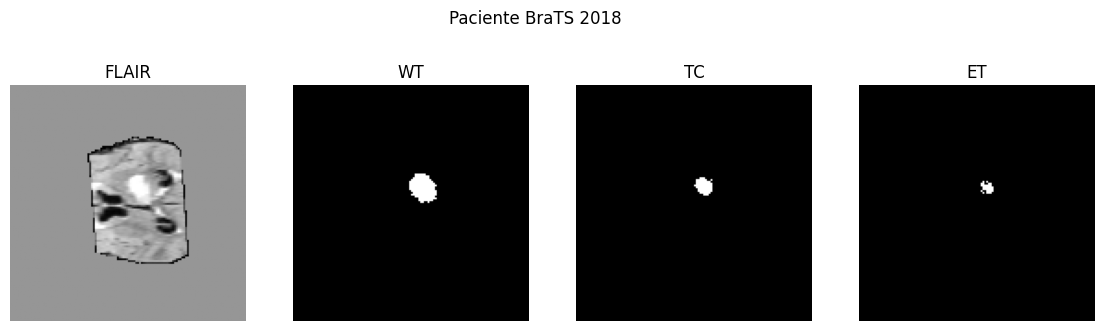

In [82]:
import matplotlib.pyplot as plt

def show_middle_slice(x, y, title="Exemplo"):
    z = x.shape[2] // 2
    flair = x[:, :, z, 0]
    wt, tc, et = y[:, :, z, 0], y[:, :, z, 1], y[:, :, z, 2]

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(flair, cmap="gray")
    plt.title("FLAIR")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(wt, cmap="gray")
    plt.title("WT")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(tc, cmap="gray")
    plt.title("TC")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(et, cmap="gray")
    plt.title("ET")
    plt.axis("off")

    plt.suptitle(title)
    plt.show()

show_middle_slice(x_test, y_test, title="Paciente BraTS 2018")


## 7. Separação treino/validação/teste: 80/10/10

O artigo usa uma separação 80% treino, 10% validação e 10% teste.

Aqui fazemos a mesma divisão por paciente, não por fatia. Isso evita vazamento de dados, porque fatias do mesmo paciente não ficam espalhadas entre treino e teste.


In [83]:
def split_cases(cases, max_cases=None):
    cases = list(cases)
    random.Random(SEED).shuffle(cases)

    if max_cases is not None:
        cases = cases[:max_cases]

    n = len(cases)
    n_train = int(0.8 * n)
    n_val = int(0.1 * n)

    train = cases[:n_train]
    val = cases[n_train:n_train+n_val]
    test = cases[n_train+n_val:]

    return train, val, test

train18, val18, test18 = split_cases(cases_2018, MAX_CASES_2018)
train20, val20, test20 = split_cases(cases_2020, MAX_CASES_2020)

print("BraTS 2018:", len(train18), len(val18), len(test18))
print("BraTS 2020:", len(train20), len(val20), len(test20))


BraTS 2018: 228 28 29
BraTS 2020: 295 36 38


## 8. Gerador de dados 3D

O gerador carrega os volumes sob demanda, para não tentar colocar o dataset inteiro na RAM.

Também adicionamos data augmentation simples em 3D:

1. flip no eixo horizontal;
2. flip no eixo vertical;
3. ruído gaussiano;
4. pequenas variações de intensidade.

Essas técnicas seguem a ideia do artigo de aumentar a variabilidade dos dados.


In [84]:
class BraTS3DSequence(tf.keras.utils.Sequence):
    def __init__(self, cases, batch_size=1, augment=False, shuffle=True):
        self.cases = list(cases)
        self.batch_size = batch_size
        self.augment = augment
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.cases) / self.batch_size))

    def on_epoch_end(self):
        self.indices = np.arange(len(self.cases))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def augment_case(self, x, y):
        if np.random.rand() < 0.5:
            x = np.flip(x, axis=0)
            y = np.flip(y, axis=0)
        if np.random.rand() < 0.5:
            x = np.flip(x, axis=1)
            y = np.flip(y, axis=1)
        if np.random.rand() < 0.3:
            noise = np.random.normal(0, 0.03, size=x.shape).astype(np.float32)
            x = np.clip(x + noise, 0, 1)
        if np.random.rand() < 0.3:
            factor = np.random.uniform(0.9, 1.1)
            x = np.clip(x * factor, 0, 1)
        return x.copy(), y.copy()

    def __getitem__(self, idx):
        batch_indices = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        xs, ys = [], []

        for i in batch_indices:
            x, y = load_case(self.cases[i])
            if self.augment:
                x, y = self.augment_case(x, y)
            xs.append(x)
            ys.append(y)

        return np.stack(xs, axis=0), np.stack(ys, axis=0)

train_gen18 = BraTS3DSequence(train18, BATCH_SIZE, augment=True, shuffle=True)
val_gen18 = BraTS3DSequence(val18, BATCH_SIZE, augment=False, shuffle=False)
test_gen18 = BraTS3DSequence(test18, BATCH_SIZE, augment=False, shuffle=False)

train_gen20 = BraTS3DSequence(train20, BATCH_SIZE, augment=True, shuffle=True)
val_gen20 = BraTS3DSequence(val20, BATCH_SIZE, augment=False, shuffle=False)
test_gen20 = BraTS3DSequence(test20, BATCH_SIZE, augment=False, shuffle=False)

xb, yb = train_gen18[0]
print("Batch X:", xb.shape)
print("Batch Y:", yb.shape)


Batch X: (2, 128, 128, 64, 4)
Batch Y: (2, 128, 128, 64, 3)


## 9. Métricas usadas no artigo

As métricas calculadas são:

```text
Dice
Jaccard / IoU
Sensibilidade
Especificidade
```

Como a saída tem 3 canais, calculamos essas métricas para:

```text
WT, TC e ET
```


In [85]:
SMOOTH = 1e-6

def dice_coef_tf(y_true, y_pred):
    y_pred = tf.cast(y_pred > THRESHOLD, tf.float32)
    y_true = tf.cast(y_true, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    denom = tf.reduce_sum(y_true + y_pred, axis=[1,2,3])
    return tf.reduce_mean((2.0 * intersection + SMOOTH) / (denom + SMOOTH))

def soft_dice_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    denom = tf.reduce_sum(y_true + y_pred, axis=[1,2,3])
    dice = (2.0 * intersection + SMOOTH) / (denom + SMOOTH)
    return 1.0 - tf.reduce_mean(dice)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return tf.reduce_mean(bce) + soft_dice_loss(y_true, y_pred)

def binary_metrics_np(y_true, y_pred, threshold=0.5):
    y_true = y_true.astype(bool)
    y_pred = (y_pred >= threshold)

    tp = np.logical_and(y_true, y_pred).sum()
    tn = np.logical_and(~y_true, ~y_pred).sum()
    fp = np.logical_and(~y_true, y_pred).sum()
    fn = np.logical_and(y_true, ~y_pred).sum()

    dice = (2*tp + SMOOTH) / (2*tp + fp + fn + SMOOTH)
    jaccard = (tp + SMOOTH) / (tp + fp + fn + SMOOTH)
    sensitivity = (tp + SMOOTH) / (tp + fn + SMOOTH)
    specificity = (tn + SMOOTH) / (tn + fp + SMOOTH)

    return {
        "dice": dice,
        "jaccard": jaccard,
        "iou": jaccard,
        "sensitivity": sensitivity,
        "specificity": specificity
    }


## 10. Modelo ACU-Net adaptado para 3D

O artigo descreve uma arquitetura U-Net com:

1. encoder;
2. bottleneck;
3. mecanismo de atenção;
4. decoder;
5. skip connections.

Aqui usamos uma versão 3D:

```text
Conv2D vira Conv3D
MaxPooling2D vira MaxPooling3D
Conv2DTranspose vira Conv3DTranspose
```

A atenção é aplicada no bottleneck, preservando a ideia central do ACU-Net.


In [86]:
def conv_block_3d(x, filters, dropout=0.0):
    x = layers.Conv3D(filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv3D(filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    if dropout > 0:
        x = layers.Dropout(dropout)(x)
    return x

def bottleneck_attention_3d(x, units):
    # x: B, H, W, D, C
    shape = K.int_shape(x)
    h, w, d, c = shape[1], shape[2], shape[3], shape[4]

    tokens = layers.Reshape((h*w*d, c))(x)
    query = layers.Dense(units)(tokens)
    value = layers.Dense(units)(tokens)

    attn = layers.Attention()([query, value])
    attn = layers.Dense(c)(attn)
    attn = layers.Reshape((h, w, d, c))(attn)

    x = layers.Add()([x, attn])
    x = layers.BatchNormalization()(x)
    return x

def build_acunet_3d(input_shape=(128, 128, 64, 4), base_filters=16):
    inputs = layers.Input(shape=input_shape)

    c1 = conv_block_3d(inputs, base_filters)
    p1 = layers.MaxPooling3D((2,2,2))(c1)

    c2 = conv_block_3d(p1, base_filters*2)
    p2 = layers.MaxPooling3D((2,2,2))(c2)

    c3 = conv_block_3d(p2, base_filters*4)
    p3 = layers.MaxPooling3D((2,2,2))(c3)

    c4 = conv_block_3d(p3, base_filters*8)
    p4 = layers.MaxPooling3D((2,2,2))(c4)

    bn = conv_block_3d(p4, base_filters*16, dropout=0.2)
    bn = bottleneck_attention_3d(bn, units=base_filters*16)

    u4 = layers.Conv3DTranspose(base_filters*8, 2, strides=(2,2,2), padding="same")(bn)
    u4 = layers.Concatenate()([u4, c4])
    c5 = conv_block_3d(u4, base_filters*8)

    u3 = layers.Conv3DTranspose(base_filters*4, 2, strides=(2,2,2), padding="same")(c5)
    u3 = layers.Concatenate()([u3, c3])
    c6 = conv_block_3d(u3, base_filters*4)

    u2 = layers.Conv3DTranspose(base_filters*2, 2, strides=(2,2,2), padding="same")(c6)
    u2 = layers.Concatenate()([u2, c2])
    c7 = conv_block_3d(u2, base_filters*2)

    u1 = layers.Conv3DTranspose(base_filters, 2, strides=(2,2,2), padding="same")(c7)
    u1 = layers.Concatenate()([u1, c1])
    c8 = conv_block_3d(u1, base_filters)

    outputs = layers.Conv3D(3, 1, activation="sigmoid")(c8)

    model = models.Model(inputs, outputs, name="ACU_Net_3D")
    return model

def build_unet_3d_baseline(input_shape=(128, 128, 64, 4), base_filters=16):
    # baseline sem atenção, útil para comparação estatística
    inputs = layers.Input(shape=input_shape)

    c1 = conv_block_3d(inputs, base_filters)
    p1 = layers.MaxPooling3D((2,2,2))(c1)
    c2 = conv_block_3d(p1, base_filters*2)
    p2 = layers.MaxPooling3D((2,2,2))(c2)
    c3 = conv_block_3d(p2, base_filters*4)
    p3 = layers.MaxPooling3D((2,2,2))(c3)
    c4 = conv_block_3d(p3, base_filters*8)
    p4 = layers.MaxPooling3D((2,2,2))(c4)

    bn = conv_block_3d(p4, base_filters*16, dropout=0.2)

    u4 = layers.Conv3DTranspose(base_filters*8, 2, strides=(2,2,2), padding="same")(bn)
    u4 = layers.Concatenate()([u4, c4])
    c5 = conv_block_3d(u4, base_filters*8)

    u3 = layers.Conv3DTranspose(base_filters*4, 2, strides=(2,2,2), padding="same")(c5)
    u3 = layers.Concatenate()([u3, c3])
    c6 = conv_block_3d(u3, base_filters*4)

    u2 = layers.Conv3DTranspose(base_filters*2, 2, strides=(2,2,2), padding="same")(c6)
    u2 = layers.Concatenate()([u2, c2])
    c7 = conv_block_3d(u2, base_filters*2)

    u1 = layers.Conv3DTranspose(base_filters, 2, strides=(2,2,2), padding="same")(c7)
    u1 = layers.Concatenate()([u1, c1])
    c8 = conv_block_3d(u1, base_filters)

    outputs = layers.Conv3D(3, 1, activation="sigmoid")(c8)
    return models.Model(inputs, outputs, name="U_Net_3D_Baseline")

input_shape = (IMG_SIZE[0], IMG_SIZE[1], DEPTH, N_MODALITIES)

start_build = time.time()
model = build_acunet_3d(input_shape=input_shape, base_filters=16)
build_time = time.time() - start_build

model.compile(
    optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
    loss=bce_dice_loss,
    metrics=[dice_coef_tf]
)

model.summary()
print("Tempo de construção do modelo:", round(build_time, 2), "segundos")


Model: "ACU_Net_3D"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 64, 4)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_19 (Conv3D)  │ (None, 128, 128,  │      1,744 │ input_layer_1[0]… │
│                     │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │         64 │ conv3d_19[0][0]   │
│ (BatchNormalizatio… │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_20 (Conv3D)  │ (None, 128, 128,  │      6,928 │ batch_normalizat… │
│                     │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │         64 │ conv3d_20[0][0]   │
│ (BatchNormalizatio… │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_4     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling3D)      │ 32, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_21 (Conv3D)  │ (None, 64, 64,    │     13,856 │ max_pooling3d_4[… │
│                     │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv3d_21[0][0]   │
│ (BatchNormalizatio… │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_22 (Conv3D)  │ (None, 64, 64,    │     27,680 │ batch_normalizat… │
│                     │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv3d_22[0][0]   │
│ (BatchNormalizatio… │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_5     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling3D)      │ 16, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_23 (Conv3D)  │ (None, 32, 32,    │     55,360 │ max_pooling3d_5[… │
│                     │ 16, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv3d_23[0][0]   │
│ (BatchNormalizatio… │ 16, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_24 (Conv3D)  │ (None, 32, 32,    │    110,656 │ batch_normalizat… │
│                     │ 16, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv3d_24[0][0]   │
│ (BatchNormalizatio… │ 16, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_6     │ (None, 16, 16, 8, │          0 │ batch_normalizat… │
│ (MaxPooling3D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_25 (Conv3D)  │ (None, 16, 16, 8, │    221,312 │ max_pooling3d_6[

 Total params: 5,850,531 (22.32 MB)

 Trainable params: 5,847,075 (22.30 MB)

 Non-trainable params: 3,456 (13.50 KB)

Tempo de construção do modelo: 0.21 segundos


## 11. Treinar o modelo

O artigo usa:

```text
até 25 épocas
early stopping
ReduceLROnPlateau
Adam
dropout 0.2
```

Aqui seguimos a mesma lógica.


In [87]:
def train_model(model, train_gen, val_gen, dataset_name):
    ckpt_path = f"/content/acunet3d_{dataset_name}.keras"

    cb = [
        callbacks.ModelCheckpoint(
            ckpt_path,
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        ),
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.2,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]

    t0 = time.time()
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        callbacks=cb
    )
    train_time = time.time() - t0

    return history, train_time, ckpt_path

history18, train_time18, ckpt18 = train_model(model, train_gen18, val_gen18, "brats2018")
print("Tempo de treinamento BraTS 2018:", round(train_time18, 2), "segundos")


Epoch 1/25
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - dice_coef_tf: 0.0176 - loss: 1.7573
Epoch 1: val_loss improved from None to 1.69372, saving model to /content/acunet3d_brats2018.keras

Epoch 1: finished saving model to /content/acunet3d_brats2018.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 394s 3s/step - dice_coef_tf: 0.0232 - loss: 1.7157 - val_dice_coef_tf: 0.0255 - val_loss: 1.6937 - learning_rate: 1.0000e-04
Epoch 2/25
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - dice_coef_tf: 0.0357 - loss: 1.6584
Epoch 2: val_loss improved from 1.69372 to 1.64760, saving model to /content/acunet3d_brats2018.keras

Epoch 2: finished saving model to /content/acunet3d_brats2018.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 377s 3s/step - dice_coef_tf: 0.0398 - loss: 1.6508 - val_dice_coef_tf: 0.0619 - val_loss: 1.6476 - learning_rate: 1.0000e-04
Epoch 3/25
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - dice_coef_tf: 0.0570 - loss: 1.6297
Epoch 3: val_loss improved from 1.64760 to 1.60524, saving model to /content/acunet3d_

## 12. Avaliação no conjunto de teste

A avaliação é feita por paciente e por região tumoral:

```text
WT, TC e ET
```

Também calculamos:

```text
tempo médio de inferência por volume
uso aproximado de memória RAM
número de parâmetros
```


In [88]:
CLASS_NAMES = ["WT", "TC", "ET"]

def current_memory_mb():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024**2)

def evaluate_model(model, test_cases, dataset_name, threshold=0.5):
    rows = []
    inference_times = []

    mem_before = current_memory_mb()

    for case in test_cases:
        x, y = load_case(case)
        x_batch = np.expand_dims(x, axis=0)

        t0 = time.time()
        pred = model.predict(x_batch, verbose=0)[0]
        inf_time = time.time() - t0
        inference_times.append(inf_time)

        for c, name in enumerate(CLASS_NAMES):
            m = binary_metrics_np(y[..., c], pred[..., c], threshold=threshold)
            rows.append({
                "dataset": dataset_name,
                "patient_id": case["patient_id"],
                "class": name,
                **m,
                "inference_time_sec": inf_time
            })

        del x, y, x_batch, pred
        gc.collect()

    mem_after = current_memory_mb()

    df = pd.DataFrame(rows)

    complexity = {
        "dataset": dataset_name,
        "model": model.name,
        "params": int(model.count_params()),
        "build_time_sec": build_time,
        "mean_inference_time_sec": float(np.mean(inference_times)),
        "total_inference_time_sec": float(np.sum(inference_times)),
        "memory_delta_mb": float(mem_after - mem_before),
        "memory_after_mb": float(mem_after)
    }

    return df, complexity

metrics18, complexity18 = evaluate_model(model, test18, "BraTS 2018", threshold=THRESHOLD)

display(metrics18.head())
display(metrics18.groupby(["dataset", "class"])[["dice", "jaccard", "iou", "sensitivity", "specificity"]].mean() * 100)
complexity18


,dataset,patient_id,class,dice,jaccard,iou,sensitivity,specificity,inference_time_sec
0,BraTS 2018,Brats18_TCIA02_607_1,WT,0.034666,0.017639,0.017639,1.000000,0.603901,0.604338
1,BraTS 2018,Brats18_TCIA02_607_1,TC,0.638245,0.468693,0.468693,1.000000,0.994454,0.604338
2,BraTS 2018,Brats18_TCIA02_607_1,ET,0.317242,0.188525,0.188525,0.985340,0.990907,0.604338
3,BraTS 2018,Brats18_CBICA_AYW_1,WT,0.796464,0.661770,0.661770,0.991745,0.998266,0.287305
4,BraTS 2018,Brats18_CBICA_AYW_1,TC,0.745250,0.593943,0.593943,0.964200,0.998752,0.287305


dice    jaccard        iou  sensitivity  specificity
dataset    class                                                           
BraTS 2018 ET     38.508132  25.416946  25.416946    90.380111    99.270688
           TC     60.745966  46.529087  46.529087    93.389519    98.606202
           WT     71.500083  59.538976  59.538976    97.077069    96.505316

{'dataset': 'BraTS 2018',
 'model': 'ACU_Net_3D',
 'params': 5850531,
 'build_time_sec': 0.21332144737243652,
 'mean_inference_time_sec': 0.2881794633536503,
 'total_inference_time_sec': 8.35720443725586,
 'memory_delta_mb': -26.16015625,
 'memory_after_mb': 5341.5234375}

## 13. Repetir o treinamento e avaliação para o BraTS 2020

O artigo também avalia o BraTS 2020. A célula abaixo cria um novo modelo ACU-Net 3D e repete o processo.


In [89]:
tf.keras.backend.clear_session()
gc.collect()

start_build20 = time.time()
model20 = build_acunet_3d(input_shape=input_shape, base_filters=16)
build_time20 = time.time() - start_build20

model20.compile(
    optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
    loss=bce_dice_loss,
    metrics=[dice_coef_tf]
)

history20, train_time20, ckpt20 = train_model(model20, train_gen20, val_gen20, "brats2020")
metrics20, complexity20 = evaluate_model(model20, test20, "BraTS 2020", threshold=THRESHOLD)

display(metrics20.groupby(["dataset", "class"])[["dice", "jaccard", "iou", "sensitivity", "specificity"]].mean() * 100)
complexity20


Epoch 1/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - dice_coef_tf: 0.0251 - loss: 1.7495
Epoch 1: val_loss improved from None to 1.59956, saving model to /content/acunet3d_brats2020.keras

Epoch 1: finished saving model to /content/acunet3d_brats2020.keras
148/148 ━━━━━━━━━━━━━━━━━━━━ 499s 3s/step - dice_coef_tf: 0.0380 - loss: 1.6972 - val_dice_coef_tf: 0.2036 - val_loss: 1.5996 - learning_rate: 1.0000e-04
Epoch 2/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - dice_coef_tf: 0.0825 - loss: 1.6267
Epoch 2: val_loss improved from 1.59956 to 1.58426, saving model to /content/acunet3d_brats2020.keras

Epoch 2: finished saving model to /content/acunet3d_brats2020.keras
148/148 ━━━━━━━━━━━━━━━━━━━━ 481s 3s/step - dice_coef_tf: 0.0938 - loss: 1.6192 - val_dice_coef_tf: 0.1947 - val_loss: 1.5843 - learning_rate: 1.0000e-04
Epoch 3/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - dice_coef_tf: 0.1598 - loss: 1.5904
Epoch 3: val_loss improved from 1.58426 to 1.55674, saving model to /content/acunet3d_

dice    jaccard        iou  sensitivity  specificity
dataset    class                                                           
BraTS 2020 ET     52.967694  39.061773  39.061773    82.051926    99.832236
           TC     64.075804  50.863735  50.863735    87.620581    99.706348
           WT     74.043927  62.450595  62.450595    95.340767    98.988850

{'dataset': 'BraTS 2020',
 'model': 'ACU_Net_3D',
 'params': 5850531,
 'build_time_sec': 0.21332144737243652,
 'mean_inference_time_sec': 0.298513694813377,
 'total_inference_time_sec': 11.343520402908325,
 'memory_delta_mb': -25.046875,
 'memory_after_mb': 5492.57421875}

## 14. Tabela final de métricas

Esta tabela resume os resultados dos dois datasets.


In [90]:
all_metrics = pd.concat([metrics18, metrics20], ignore_index=True)

summary = (
    all_metrics
    .groupby(["dataset", "class"])[["dice", "jaccard", "iou", "sensitivity", "specificity"]]
    .mean()
    .reset_index()
)

summary_percent = summary.copy()
for col in ["dice", "jaccard", "iou", "sensitivity", "specificity"]:
    summary_percent[col] = summary_percent[col] * 100

display(summary_percent)

summary_percent.to_csv("/content/resultados_metricas_acunet3d.csv", index=False)
all_metrics.to_csv("/content/resultados_por_paciente_acunet3d.csv", index=False)

print("Arquivos salvos:")
print("/content/resultados_metricas_acunet3d.csv")
print("/content/resultados_por_paciente_acunet3d.csv")


,dataset,class,dice,jaccard,iou,sensitivity,specificity
0,BraTS 2018,ET,38.508132,25.416946,25.416946,90.380111,99.270688
1,BraTS 2018,TC,60.745966,46.529087,46.529087,93.389519,98.606202
2,BraTS 2018,WT,71.500083,59.538976,59.538976,97.077069,96.505316
3,BraTS 2020,ET,52.967694,39.061773,39.061773,82.051926,99.832236
4,BraTS 2020,TC,64.075804,50.863735,50.863735,87.620581,99.706348
5,BraTS 2020,WT,74.043927,62.450595,62.450595,95.340767,98.988850


Arquivos salvos:
/content/resultados_metricas_acunet3d.csv
/content/resultados_por_paciente_acunet3d.csv


## 15. Comparação com os resultados reportados no artigo

A tabela abaixo coloca os resultados do artigo ao lado dos resultados deste notebook.

Atenção:

1. os valores do artigo são do ACU-Net em 2D;
2. os valores deste notebook são da adaptação 3D;
3. os resultados podem variar por GPU, número de épocas, modo `quick/full`, seed, pré-processamento e disponibilidade exata dos dados.


In [93]:
article_results = pd.DataFrame([
    {"dataset": "BraTS 2018", "class": "WT", "article_dice_percent": 99.23},
    {"dataset": "BraTS 2018", "class": "TC", "article_dice_percent": 99.27},
    {"dataset": "BraTS 2018", "class": "ET", "article_dice_percent": 96.99},
    {"dataset": "BraTS 2020", "class": "WT", "article_dice_percent": 98.72},
    {"dataset": "BraTS 2020", "class": "TC", "article_dice_percent": 98.40},
    {"dataset": "BraTS 2020", "class": "ET", "article_dice_percent": 97.66},
])

comparison = summary_percent.merge(article_results, on=["dataset", "class"], how="left")
comparison["difference_vs_article_dice"] = comparison["dice"] - comparison["article_dice_percent"]

display(comparison)
comparison.to_csv("/content/comparacao_com_artigo_acunet3d.csv", index=False)


,dataset,class,dice,jaccard,iou,sensitivity,specificity,article_dice_percent,difference_vs_article_dice
0,BraTS 2018,ET,38.508132,25.416946,25.416946,90.380111,99.270688,96.99,-58.481868
1,BraTS 2018,TC,60.745966,46.529087,46.529087,93.389519,98.606202,99.27,-38.524034
2,BraTS 2018,WT,71.500083,59.538976,59.538976,97.077069,96.505316,99.23,-27.729917
3,BraTS 2020,ET,52.967694,39.061773,39.061773,82.051926,99.832236,97.66,-44.692306
4,BraTS 2020,TC,64.075804,50.863735,50.863735,87.620581,99.706348,98.40,-34.324196
5,BraTS 2020,WT,74.043927,62.450595,62.450595,95.340767,98.988850,98.72,-24.676073


## 16. Análise de desempenho computacional

O artigo também apresenta uma análise de complexidade com:

```text
Build Time
Inference Time
Memory Usage
```

Aqui salvamos uma tabela semelhante, com informações adicionais.


In [126]:
complexity20["build_time_sec"] = build_time20

complexity_df = pd.DataFrame([complexity18, complexity20])
display(complexity_df)

complexity_df.to_csv("/content/complexidade_acunet3d.csv", index=False)
print("/content/complexidade_acunet3d.csv")


,dataset,model,params,build_time_sec,mean_inference_time_sec,total_inference_time_sec,memory_delta_mb,memory_after_mb
0,BraTS 2018,ACU_Net_3D,5850531,0.213321,0.288179,8.357204,-26.160156,5341.523438
1,BraTS 2020,ACU_Net_3D,5850531,0.215039,0.298514,11.343520,-25.046875,5492.574219


/content/complexidade_acunet3d.csv


## 17. Curvas de treinamento

Estas curvas ajudam a verificar se o modelo está aprendendo ou se está sofrendo overfitting.


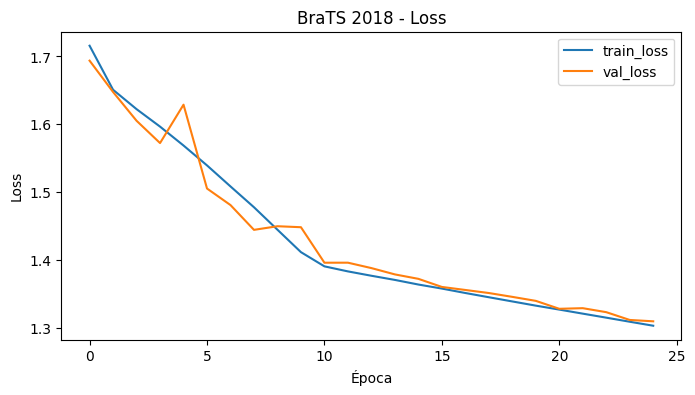

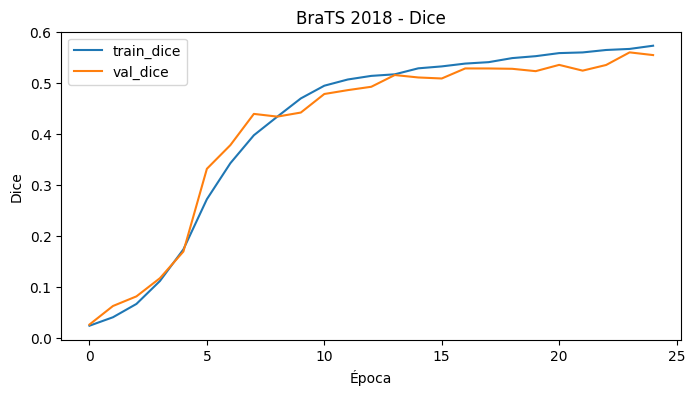

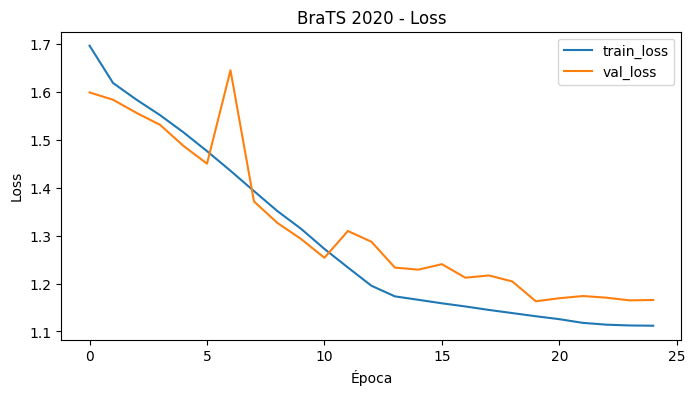

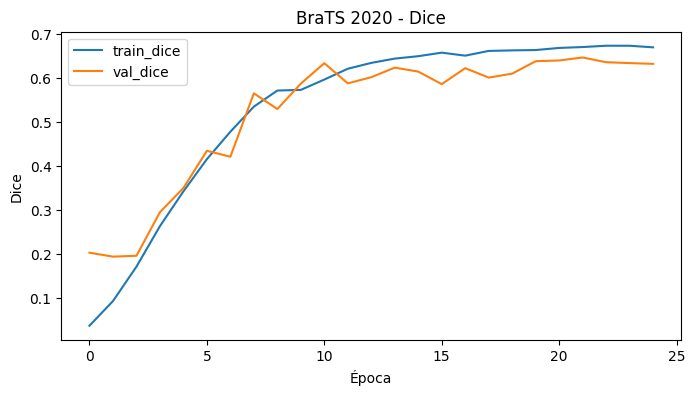

In [95]:
def plot_history(history, title):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(8, 4))
    plt.plot(hist["loss"], label="train_loss")
    if "val_loss" in hist:
        plt.plot(hist["val_loss"], label="val_loss")
    plt.title(title + " - Loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    if "dice_coef_tf" in hist:
        plt.figure(figsize=(8, 4))
        plt.plot(hist["dice_coef_tf"], label="train_dice")
        if "val_dice_coef_tf" in hist:
            plt.plot(hist["val_dice_coef_tf"], label="val_dice")
        plt.title(title + " - Dice")
        plt.xlabel("Época")
        plt.ylabel("Dice")
        plt.legend()
        plt.show()

plot_history(history18, "BraTS 2018")
plot_history(history20, "BraTS 2020")


## 18. Visualização 2D da segmentação

A célula abaixo mostra:

1. imagem FLAIR;
2. máscara real;
3. máscara prevista;
4. sobreposição da previsão na imagem.

Isso é útil para validar visualmente os resultados antes da renderização 3D.


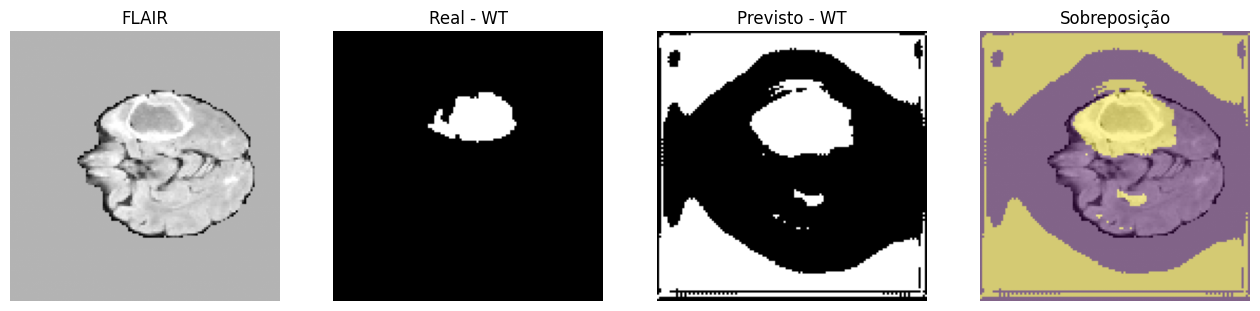

In [96]:
def predict_case(model, case):
    x, y = load_case(case)
    pred = model.predict(np.expand_dims(x, axis=0), verbose=0)[0]
    return x, y, pred

def show_prediction_slices(model, case, class_idx=0, z=None, threshold=0.5):
    x, y, pred = predict_case(model, case)

    if z is None:
        # Escolhe a fatia com maior tumor real para a classe selecionada
        sums = y[..., class_idx].sum(axis=(0,1))
        z = int(np.argmax(sums))

    img = x[:, :, z, 0]
    gt = y[:, :, z, class_idx]
    pr = pred[:, :, z, class_idx] >= threshold

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(img, cmap="gray")
    plt.title("FLAIR")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(gt, cmap="gray")
    plt.title(f"Real - {CLASS_NAMES[class_idx]}")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(pr, cmap="gray")
    plt.title(f"Previsto - {CLASS_NAMES[class_idx]}")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(img, cmap="gray")
    plt.imshow(pr, alpha=0.45)
    plt.title("Sobreposição")
    plt.axis("off")

    plt.show()

    return x, y, pred

# Exemplo BraTS 2018
x_vis, y_vis, pred_vis = show_prediction_slices(model, test18[0], class_idx=0)


## 19. Visualização 3D da segmentação

Aqui geramos uma visualização 3D da máscara prevista.

A ideia é transformar o volume binário em uma malha 3D usando `marching_cubes`.

Você pode visualizar:

```text
WT, TC ou ET
```

No Plotly, é possível girar a imagem 3D com o mouse.


In [127]:
def mask_to_mesh(mask, threshold=0.5, step_size=2):
    mask = (mask >= threshold).astype(np.float32)

    if mask.sum() == 0:
        return None, None

    verts, faces, normals, values = measure.marching_cubes(
        mask,
        level=0.5,
        step_size=step_size
    )
    return verts, faces

def plot_3d_mask(mask, title="Segmentação 3D", threshold=0.5, opacity=0.5):
    verts, faces = mask_to_mesh(mask, threshold=threshold)

    if verts is None:
        print("Máscara vazia. Nada para plotar.")
        return None

    fig = go.Figure(data=[
        go.Mesh3d(
            x=verts[:, 0],
            y=verts[:, 1],
            z=verts[:, 2],
            i=faces[:, 0],
            j=faces[:, 1],
            k=faces[:, 2],
            opacity=opacity
        )
    ])

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Z"
        ),
        width=800,
        height=700
    )

    fig.show()
    return fig

# Visualização 3D da previsão WT
fig_wt = plot_3d_mask(pred_vis[..., 0], title="Predição 3D - WT", threshold=THRESHOLD)


## 20. Visualizar real vs previsto em 3D

A célula abaixo gera duas malhas 3D:

1. máscara real;
2. máscara prevista.

Isso ajuda a comparar visualmente o quanto a previsão se aproxima do ground truth.


In [128]:
def plot_3d_gt_vs_pred(y_true, y_pred, class_idx=0, threshold=0.5, title="Real vs Previsto 3D"):
    gt = y_true[..., class_idx]
    pr = y_pred[..., class_idx]

    verts_gt, faces_gt = mask_to_mesh(gt, threshold=threshold)
    verts_pr, faces_pr = mask_to_mesh(pr, threshold=threshold)

    fig = go.Figure()

    if verts_gt is not None:
        fig.add_trace(go.Mesh3d(
            x=verts_gt[:, 0], y=verts_gt[:, 1], z=verts_gt[:, 2],
            i=faces_gt[:, 0], j=faces_gt[:, 1], k=faces_gt[:, 2],
            opacity=0.35,
            name="Real"
        ))

    if verts_pr is not None:
        fig.add_trace(go.Mesh3d(
            x=verts_pr[:, 0], y=verts_pr[:, 1], z=verts_pr[:, 2],
            i=faces_pr[:, 0], j=faces_pr[:, 1], k=faces_pr[:, 2],
            opacity=0.35,
            name="Previsto"
        ))

    fig.update_layout(
        title=title + f" - {CLASS_NAMES[class_idx]}",
        scene=dict(xaxis_title="X", yaxis_title="Y", zaxis_title="Z"),
        width=850,
        height=700
    )

    fig.show()
    return fig

fig_compare = plot_3d_gt_vs_pred(y_vis, pred_vis, class_idx=0, threshold=THRESHOLD, title="Máscara real vs previsão")


## 21. Salvar as visualizações 3D em HTML

O arquivo HTML pode ser aberto depois no navegador.


In [72]:
OUTPUT_DIR = Path("/content/outputs_acunet3d")
OUTPUT_DIR.mkdir(exist_ok=True)

if fig_wt is not None:
    fig_wt.write_html(str(OUTPUT_DIR / "predicao_3d_wt.html"))

if fig_compare is not None:
    fig_compare.write_html(str(OUTPUT_DIR / "real_vs_previsto_3d_wt.html"))

print("Visualizações salvas em:")
print(OUTPUT_DIR)


Visualizações salvas em:
\content\outputs_acunet3d


## 22. Teste estatístico pareado

O artigo usa teste t pareado para comparar ACU-Net com outro modelo.

Como este notebook adapta o ACU-Net para 3D, uma comparação justa é treinar também uma baseline **3D U-Net sem atenção** e comparar os Dice por paciente.

Para economizar tempo, essa parte fica opcional.


In [73]:
TRAIN_BASELINE = True  # altere para True se quiser treinar a baseline 3D U-Net sem atenção

if TRAIN_BASELINE:
    tf.keras.backend.clear_session()
    gc.collect()

    baseline = build_unet_3d_baseline(input_shape=input_shape, base_filters=16)
    baseline.compile(
        optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
        loss=bce_dice_loss,
        metrics=[dice_coef_tf]
    )

    hist_base18, train_time_base18, ckpt_base18 = train_model(
        baseline, train_gen18, val_gen18, "baseline_brats2018"
    )

    baseline_metrics18, baseline_complexity18 = evaluate_model(
        baseline, test18, "BraTS 2018 Baseline", threshold=THRESHOLD
    )

    # Teste t pareado por classe usando Dice por paciente
    rows = []
    for cls in CLASS_NAMES:
        acu = metrics18[metrics18["class"] == cls].sort_values("patient_id")["dice"].values
        base = baseline_metrics18[baseline_metrics18["class"] == cls].sort_values("patient_id")["dice"].values
        n = min(len(acu), len(base))
        t_stat, p_value = ttest_rel(acu[:n], base[:n])
        rows.append({
            "class": cls,
            "t_stat": t_stat,
            "p_value": p_value,
            "mean_acunet3d_dice": acu[:n].mean(),
            "mean_baseline3d_dice": base[:n].mean()
        })

    ttest_df = pd.DataFrame(rows)
    display(ttest_df)
    ttest_df.to_csv("/content/ttest_acunet3d_vs_baseline3d.csv", index=False)
else:
    print("Baseline não treinada. Para rodar, defina TRAIN_BASELINE = True.")


Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - dice_coef_tf: 0.0163 - loss: 1.8443
Epoch 1: val_loss improved from None to 1.66538, saving model to /content/acunet3d_baseline_brats2018.keras

Epoch 1: finished saving model to /content/acunet3d_baseline_brats2018.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - dice_coef_tf: 0.0159 - loss: 1.8319 - val_dice_coef_tf: 0.0321 - val_loss: 1.6654 - learning_rate: 1.0000e-04
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - dice_coef_tf: 0.0184 - loss: 1.8000
Epoch 2: val_loss improved from 1.66538 to 1.65791, saving model to /content/acunet3d_baseline_brats2018.keras

Epoch 2: finished saving model to /content/acunet3d_baseline_brats2018.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - dice_coef_tf: 0.0165 - loss: 1.7947 - val_dice_coef_tf: 0.1495 - val_loss: 1.6579 - learning_rate: 1.0000e-04
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - dice_coef_tf: 0.0185 - loss: 1.7699
Epoch 3: val_loss improved from 1.65791 to 1.65229, saving model to /conten

,class,t_stat,p_value,mean_acunet3d_dice,mean_baseline3d_dice
0,WT,-2.128712,0.279585,3.333193e-02,0.428801
1,TC,5.332532,0.118013,2.967865e-02,0.017491
2,ET,-1.000000,0.500000,1.200888e-11,0.058724


## 23. Gerar um relatório final em CSV

Ao final, você terá:

```text
resultados_metricas_acunet3d.csv
resultados_por_paciente_acunet3d.csv
comparacao_com_artigo_acunet3d.csv
complexidade_acunet3d.csv
outputs_acunet3d/*.html
```


In [ ]:
# Compactar resultados para baixar
!zip -r /content/resultados_acunet3d.zip /content/resultados_metricas_acunet3d.csv /content/resultados_por_paciente_acunet3d.csv /content/comparacao_com_artigo_acunet3d.csv /content/complexidade_acunet3d.csv /content/outputs_acunet3d

print("Arquivo final:")
print("/content/resultados_acunet3d.zip")


# Conclusão do notebook

Este notebook executa uma versão 3D inspirada no ACU-Net do artigo.

O que foi mantido do artigo:

1. datasets BraTS 2018 e BraTS 2020;
2. separação 80/10/10;
3. pré-processamento com resize, denoising, normalização, slicing adaptativo e augmentação;
4. arquitetura baseada em U-Net com atenção;
5. avaliação das regiões WT, TC e ET;
6. métricas Dice, Jaccard/IoU, Sensibilidade e Especificidade;
7. análise de desempenho computacional.

O que foi modificado:

1. a entrada passou de fatias 2D para volume 3D;
2. as camadas Conv2D foram adaptadas para Conv3D;
3. a visualização final mostra a segmentação em 3D.
